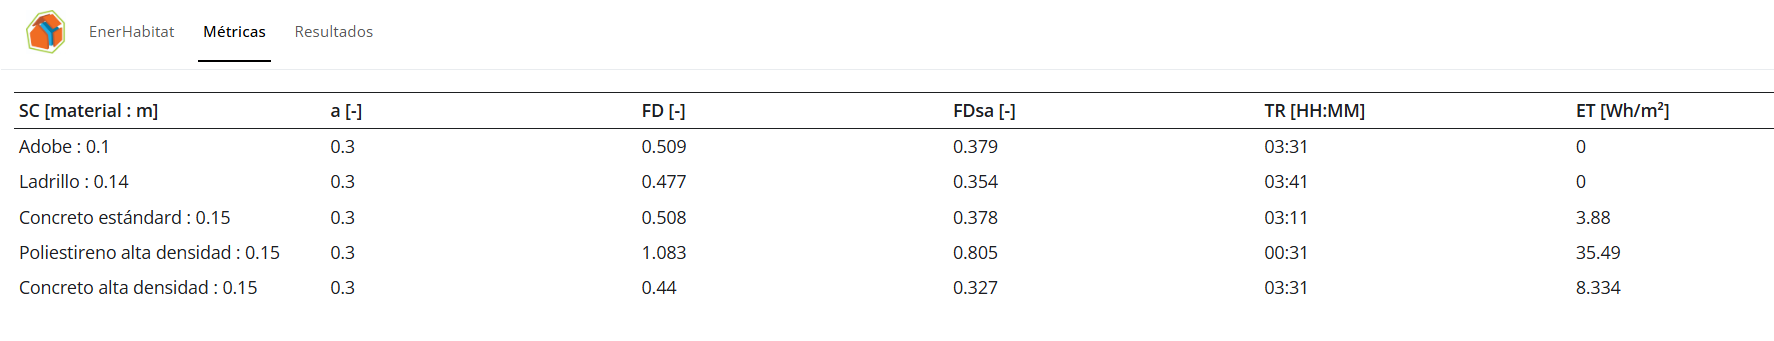

In [1]:
import enerhabitat as eh
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql

In [2]:
def evaluar(material, espesor, f):
    eh.config.Nx = 500
    muro = eh.System(eh.Location(epw_file))
    muro.azimuth = 90
    muro.absortance = 0.3
    muro.layers = [(material, espesor)]
    muro.location.meanDay(month=5, year=2025)

    # Ti y Tsa comparten la rejilla dt -> concat sin NaN (ya no hace falta asfreq)
    data = muro.solve()
    data = pd.concat([data, muro.Tsa()], axis=1)
    data.index = data.index.tz_localize(None)
    muro.info()

    # E+ etiqueta cada valor al FINAL del intervalo
    ep = read_sql(f, alias=True).data

    # Error con signo (EH - E+), EH evaluado en las marcas de tiempo de E+
    error = (data.Ti.reindex(ep.index) - ep.Ti_CUBO).dropna()
    rmse = (error**2).mean()**0.5
    mae = error.abs().mean()
    print(f"{material} {espesor*100:.0f} cm  RMSE = {rmse:.3f} C   MAE = {mae:.3f} C")

    fig, ax = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

    ax[0].plot(data.Ti, "k.", markevery=1200, label='Ti_EH')
    ax[0].plot(ep.Ti_CUBO, label='Ti_E+')
    ax[0].set_ylabel('Ti [C]')
    ax[0].legend()

    # Error con signo (EH - E+)
    ax[1].plot(error, color='tab:red', label='Error (EH - E+)')
    ax[1].axhline(0, color='k', lw=0.8)
    ax[1].set_ylabel('Error [C]')
    ax[1].set_title(f"RMSE = {rmse:.3f} C     MAE = {mae:.3f} C")
    ax[1].legend()

    ax[2].plot(data.Is, label='Is')
    ax[2].plot(data.Ig, label='Ig')
    ax[2].set_ylabel('Irradiancia [W/m2]')
    ax[2].legend()

    plt.tight_layout()

In [3]:
eh.config.file = "materials.ini"
epw_file = "../epw/Temixco_2018CST.epw"


## Validacion Adobe 0.1

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: 19766.08264186336
Cooling energy: None
Heating energy: None
Layers:
	1: Adobe, 0.1 m
Adobe 10 cm  RMSE = 0.025 C   MAE = 0.022 C


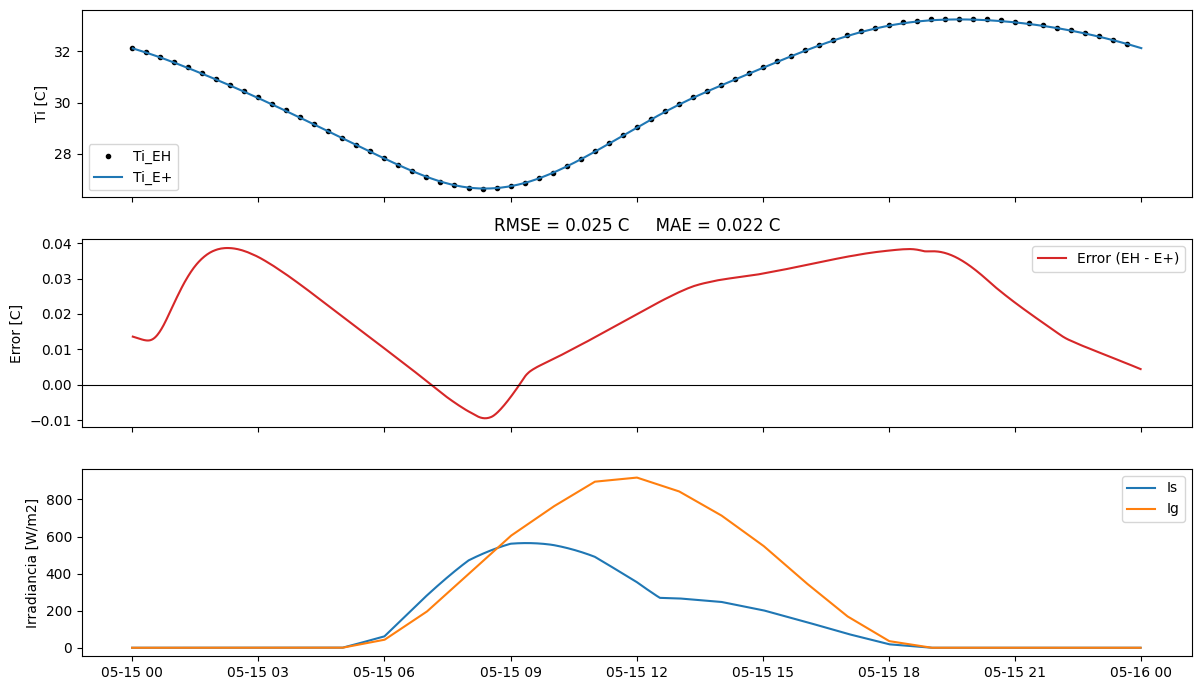

In [4]:
material = 'Adobe'
espesor = 0.1
f = '../idf/10cmAdobe.sql'

evaluar(material,espesor,f)

## Ladrillo 0.1 

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: 28182.175212019545
Cooling energy: None
Heating energy: None
Layers:
	1: Ladrillo, 0.1 m
Ladrillo 10 cm  RMSE = 0.028 C   MAE = 0.023 C


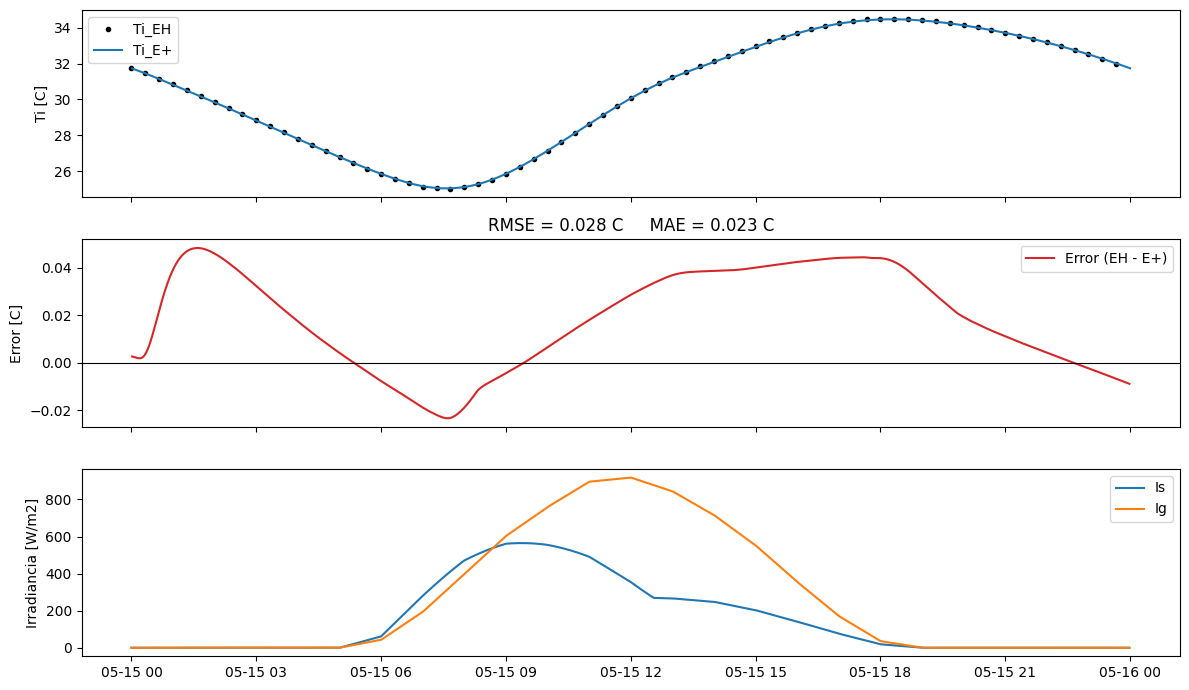

In [5]:
material = 'Ladrillo'
espesor = 0.10
f = '../idf/10cmLadrillo.sql'

evaluar(material,espesor,f)

## Concreto est'andard 0.1 

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: 30358.14761428515
Cooling energy: None
Heating energy: None
Layers:
	1: Concreto, 0.1 m
Concreto 10 cm  RMSE = 0.028 C   MAE = 0.022 C


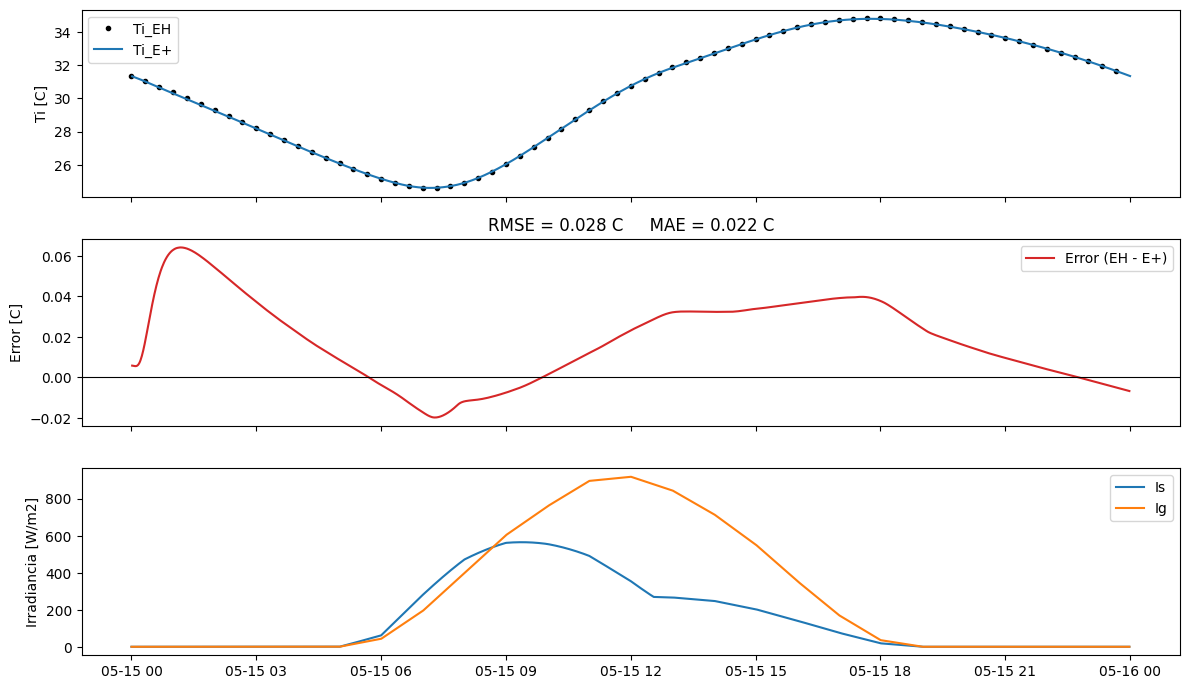

In [6]:
material = 'Concreto'
espesor = 0.10
f = '../idf/10cmConcreto.sql'

evaluar(material,espesor,f)

## EPS 0.10

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: 38209.55592317839
Cooling energy: None
Heating energy: None
Layers:
	1: EPS, 0.1 m
EPS 10 cm  RMSE = 0.377 C   MAE = 0.344 C


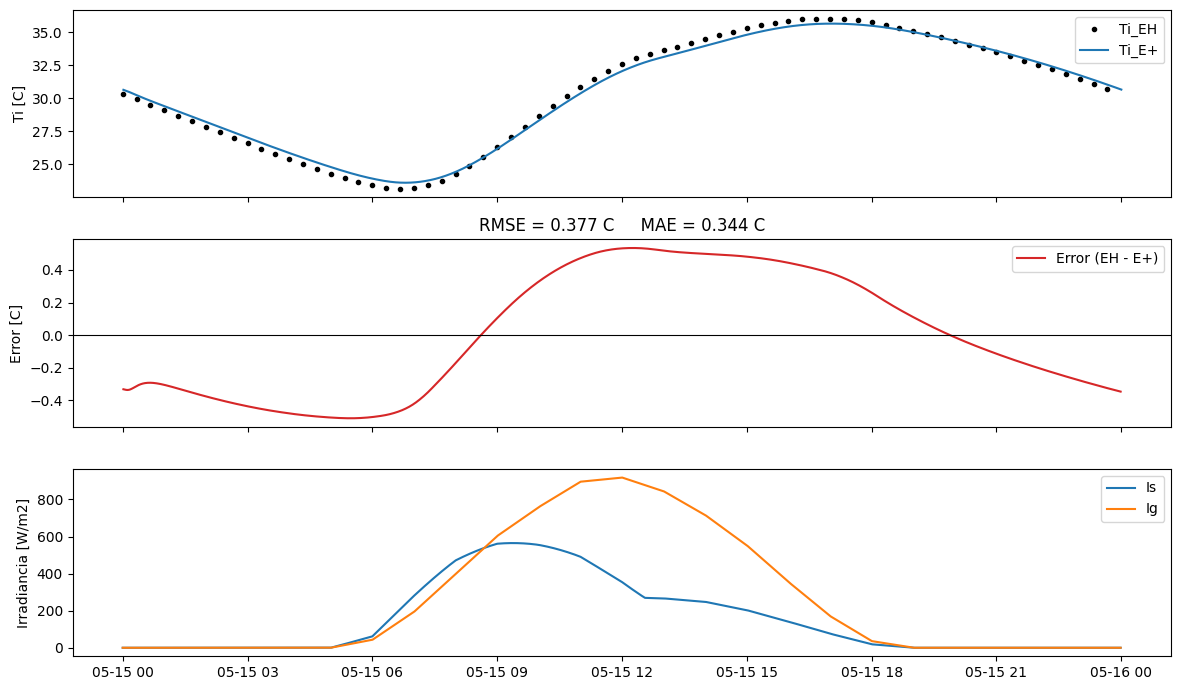

In [7]:
material = 'EPS'#Este es el que tenías con un modelo diferente
espesor = 0.10 
f = '../idf/10cmEPS.sql'

evaluar(material,espesor,f)

## CAD 0.1

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: 26717.032732836684
Cooling energy: None
Heating energy: None
Layers:
	1: CAD, 0.1 m
CAD 10 cm  RMSE = 0.026 C   MAE = 0.021 C


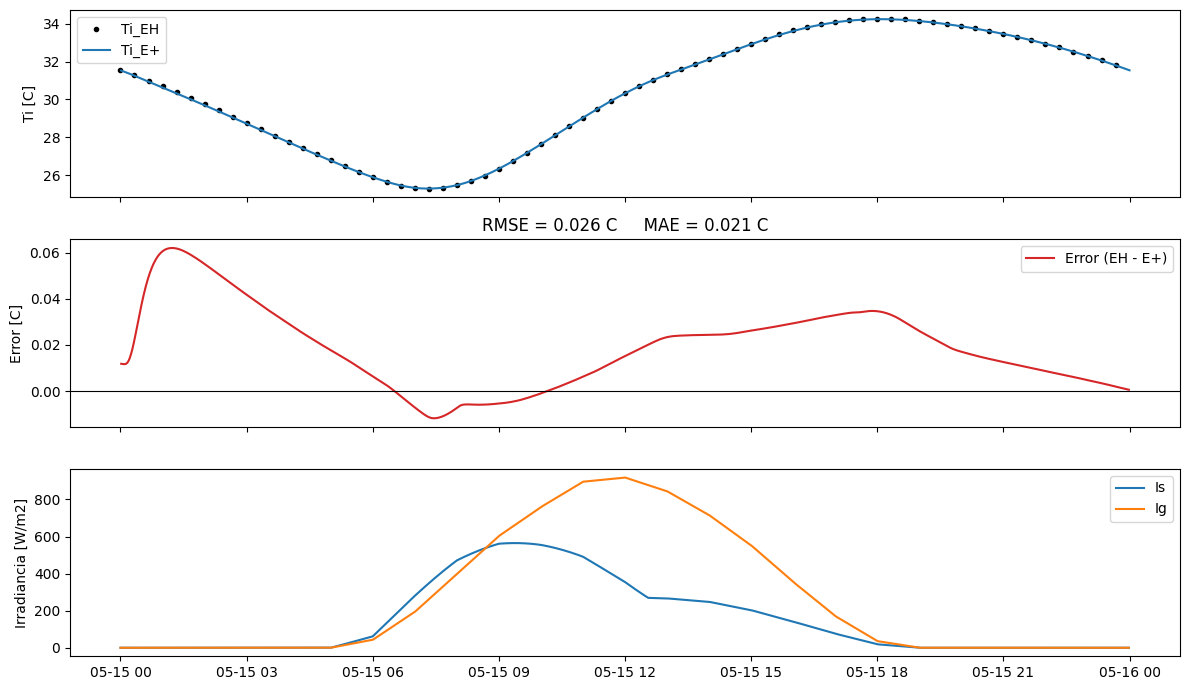

In [8]:
material = 'CAD'
espesor = 0.10
f = '../idf/10cmCAD.sql'

evaluar(material,espesor,f)

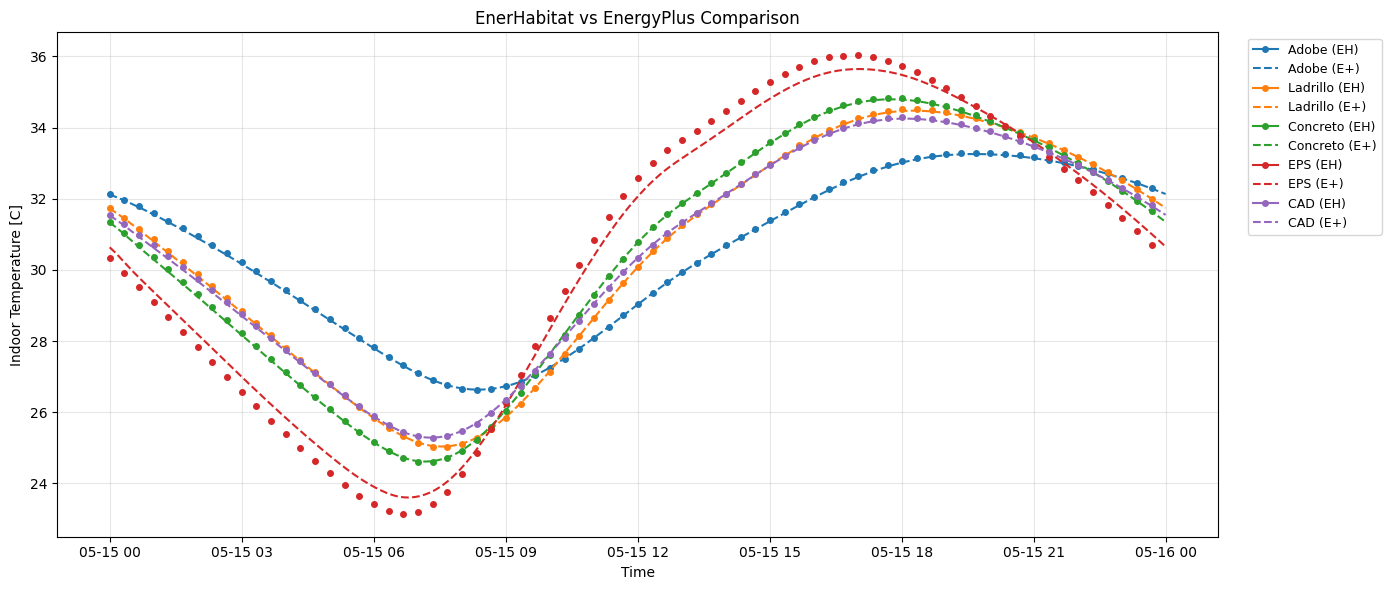

In [9]:
def evaluate_data(material, thickness, f):
    """Devuelve series EH vs E+ ya alineadas (sin shift, sin NaN)."""
    wall = eh.System(eh.Location(epw_file))
    wall.azimuth = 90
    wall.absortance = 0.3
    wall.layers = [(material, thickness)]
    wall.location.meanDay(month=5, year=2025)

    data = wall.solve()
    data = pd.concat([data, wall.Tsa()], axis=1)
    data.index = data.index.tz_localize(None)

    # E+ etiqueta al FINAL del intervalo; -60 s para alinear con EH
    eplus = read_sql(f, alias=True).data
    eplus.index = eplus.index - pd.Timedelta(seconds=60)

    return {
        'Ti_EH': data.Ti,
        'Ti_EP': eplus.Ti_CUBO,
    }

# Define all cases to evaluate
cases = [
    {'material': 'Adobe',    'thickness': 0.10, 'f': '../idf/10cmAdobe.sql'},
    {'material': 'Ladrillo', 'thickness': 0.10, 'f': '../idf/10cmLadrillo.sql'},
    {'material': 'Concreto', 'thickness': 0.10, 'f': '../idf/10cmConcreto.sql'},
    {'material': 'EPS',      'thickness': 0.10, 'f': '../idf/10cmEPS.sql'},
    {'material': 'CAD',      'thickness': 0.10, 'f': '../idf/10cmCAD.sql'},
]

# Collect all results
results = {}
for case in cases:
    name = case['material']
    results[name] = evaluate_data(case['material'], case['thickness'], case['f'])

# Create consolidated visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Color palette
colors = plt.cm.tab10.colors

# EH esta a paso dt (10 s) -> 1 marca cada 10 min = 600 s / dt puntos.
# markevery NO quita datos: dibuja toda la serie y solo marca cada N puntos.
mark_every = 1200

for i, (name, data) in enumerate(results.items()):
    color = colors[i]

    # EnerHabitat: linea continua con marca cada 10 min
    ax.plot(data['Ti_EH'],
            color=color,
            linestyle='-',
            linewidth=1.5,
            marker='o',
            markevery=mark_every,
            markersize=4,
            label=f"{name} (EH)")

    # EnergyPlus: dashed line
    ax.plot(data['Ti_EP'],
            color=color,
            linestyle='--',
            linewidth=1.5,
            label=f"{name} (E+)")

ax.set_xlabel('Time')
ax.set_ylabel('Indoor Temperature [C]')
ax.set_title('EnerHabitat vs EnergyPlus Comparison')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()